2026-04-30 01:56:16.049757: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777514176.256335      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777514176.321247      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777514176.798801      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777514176.798860      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777514176.798863      16 computation_placer.cc:177] computation placer alr

Device: cpu
Total valid Messidor-2 images: 1744
Label distribution:
label
0    1017
1     270
2     347
3      75
4      35
Name: count, dtype: int64
✔ ViT loaded


2026-04-30 01:56:57.548239: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


✔ CNN loaded | input shape: (None, 320, 320, 3)
Running inference...


Batches: 100%|██████████| 218/218 [1:10:44<00:00, 19.47s/it]


Collected: 1744 ViT | 1744 CNN | 1744 labels
ViT — min:0.00 max:3.97 mean:0.46
CNN — min:0.00 max:3.81 mean:0.42
Labels — unique: [0 1 2 3 4]

MESSIDOR-2 CROSS-DATASET RESULTS
Total images evaluated : 1744

ViT  (RETFound-Green)  : Kappa = 0.6569
CNN  (EfficientNet-B5) : Kappa = 0.5688
Ensemble (ViT + CNN)   : Kappa = 0.6286

APTOS val : ViT=0.90 | CNN=0.88
Messidor  : ViT=0.6569 | CNN=0.5688 | Ensemble=0.6286
Drop      : ViT=0.2431 | CNN=0.3112


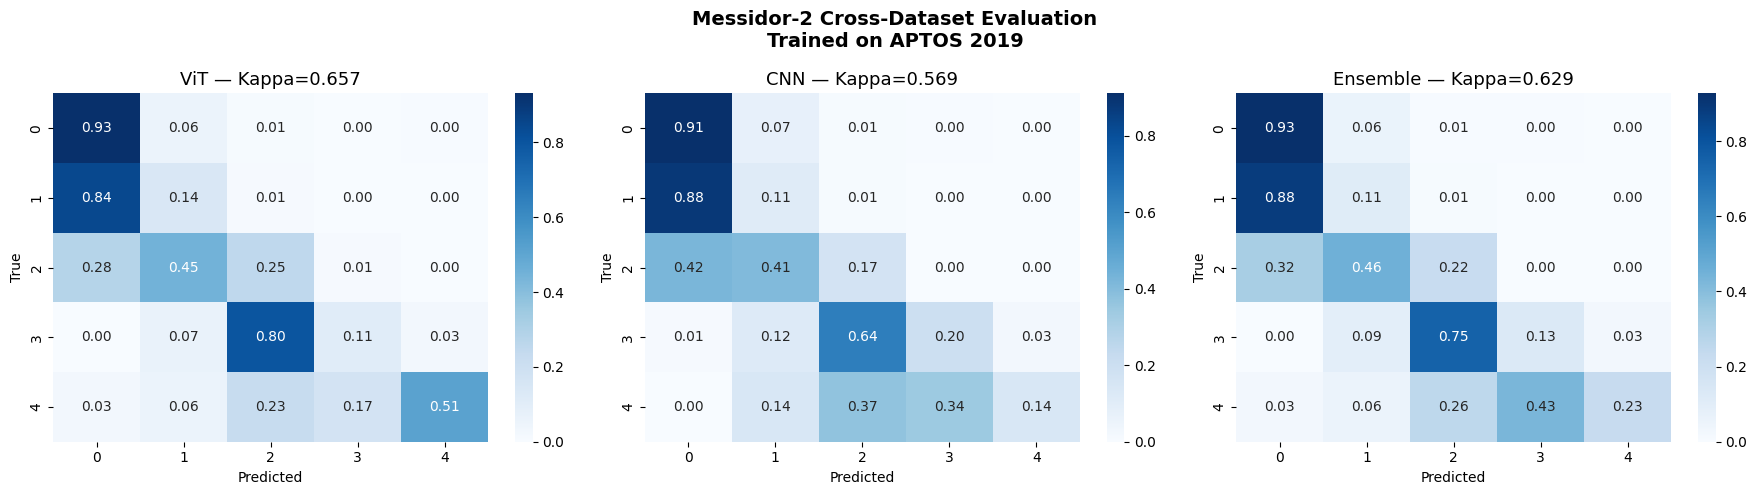

✔ Saved messidor_comparison.png


In [1]:
# === CELL 1: Imports ===
!pip install -q timm

import torch
import torch.nn as nn
import torchvision.transforms.v2 as T
import tensorflow as tf
import pandas as pd
import numpy as np
import cv2
import os
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import cohen_kappa_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

# === CELL 2: Preprocessing ===
def crop_image(img, tol=7):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    mask = gray > tol
    if not mask.any(): return img
    return img[np.ix_(mask.any(1), mask.any(0))]

def circle_crop(img):
    img = crop_image(img)
    h, w, _ = img.shape
    side = max(h, w)
    img = cv2.resize(img, (side, side))
    x, y = side // 2, side // 2
    r = min(x, y)
    mask = np.zeros((side, side), np.uint8)
    cv2.circle(mask, (x, y), r, 1, -1)
    img = cv2.bitwise_and(img, img, mask=mask)
    return crop_image(img)

def graham_preprocess(img_path, size):
    img = cv2.imread(img_path)
    if img is None:
        return np.zeros((size, size, 3), dtype=np.uint8)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = circle_crop(img)
    img = cv2.resize(img, (size, size))
    img = cv2.addWeighted(img, 4, cv2.GaussianBlur(img, (0, 0), 10), -4, 128)
    return img

# === CELL 3: Load Messidor ===
df = pd.read_csv('/kaggle/input/datasets/xyaustin/messidor2/messidor-2/messidor_data.csv')
df = df[['image_id', 'adjudicated_dr_grade']].dropna()
df.columns = ['filename', 'label']
df['filepath'] = '/kaggle/input/datasets/xyaustin/messidor2/messidor-2/images/' + df['filename']
df = df[df['filepath'].apply(os.path.exists)].reset_index(drop=True)
df['label'] = df['label'].astype(int)

print(f"Total valid Messidor-2 images: {len(df)}")
print(f"Label distribution:\n{df['label'].value_counts().sort_index()}")

# === CELL 4: Load Models ===
import timm

# -- ViT --
class GreenRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.vit = timm.create_model(
            'vit_small_patch14_reg4_dinov2',
            img_size=384,
            num_classes=0
        )
        self.vit.global_pool = 'avg'
        self.head = nn.Sequential(
            nn.Linear(384, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.head(self.vit(x)).squeeze(-1) * 4.0

vit = GreenRegressor()
state_dict = torch.load(
    '/kaggle/input/datasets/siriusspec/vitgreen2/vit_green_best (2).pth',
    map_location='cpu'
)
state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}
vit.load_state_dict(state_dict, strict=True)
vit = vit.to(device)
vit.eval()
print("✔ ViT loaded")

# -- CNN --
cnn = tf.keras.models.load_model(
    '/kaggle/input/datasets/siriusspec/dr-model-dataset/best_dr_model.h5',
    compile=False
)
print(f"✔ CNN loaded | input shape: {cnn.input_shape}")

# === CELL 5: Dataset ===
class MessidorDS(Dataset):
    def __init__(self, df):
        self.df = df
        self.normalize = T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))

    def __len__(self): return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        img_vit = graham_preprocess(row.filepath, 384)
        img_vit = torch.from_numpy(img_vit).permute(2, 0, 1).float() / 255.0
        img_vit = self.normalize(img_vit)
        return img_vit, int(row.label), row.filepath

loader = DataLoader(MessidorDS(df), batch_size=8,
                    shuffle=False, num_workers=2)

# === CELL 6: TTA ===
def tta_predict_vit(model, img_batch):
    with torch.no_grad():
        p1 = model(img_batch)
        p2 = model(torch.flip(img_batch, dims=[3]))
        p3 = model(torch.flip(img_batch, dims=[2]))
        return ((p1 + p2 + p3) / 3.0).cpu().numpy()

def preprocess_for_cnn(img_path):
    img = graham_preprocess(img_path, 320)
    return img.astype(np.float32) / 255.0

def tta_predict_cnn(model, img_paths):
    orig  = np.stack([preprocess_for_cnn(p) for p in img_paths])
    hflip = orig[:, :, ::-1, :].copy()
    vflip = orig[:, ::-1, :, :].copy()
    p1 = np.atleast_1d(model.predict(orig,  verbose=0).squeeze())
    p2 = np.atleast_1d(model.predict(hflip, verbose=0).squeeze())
    p3 = np.atleast_1d(model.predict(vflip, verbose=0).squeeze())
    return ((p1 + p2 + p3) / 3.0).flatten()

# === CELL 7: Inference ===
from tqdm import tqdm

vit_preds_raw, cnn_preds_raw, labels = [], [], []

print("Running inference...")
for batch_idx, (img_torch, y, paths) in enumerate(tqdm(loader, desc="Batches")):
    try:
        img_torch = img_torch.to(device)

        vit_out = tta_predict_vit(vit, img_torch)
        vit_preds_raw.extend(np.atleast_1d(vit_out.flatten()).tolist())

        cnn_out = tta_predict_cnn(cnn, paths)
        cnn_preds_raw.extend(np.atleast_1d(cnn_out).tolist())

        labels.extend(y.numpy().tolist())

    except Exception as e:
        print(f"Batch {batch_idx} failed: {e}")
        continue

vit_preds_raw = np.clip(np.array(vit_preds_raw), 0, 4)
cnn_preds_raw = np.clip(np.array(cnn_preds_raw), 0, 4)
labels        = np.array(labels)

print(f"Collected: {len(vit_preds_raw)} ViT | {len(cnn_preds_raw)} CNN | {len(labels)} labels")
print(f"ViT — min:{vit_preds_raw.min():.2f} max:{vit_preds_raw.max():.2f} mean:{vit_preds_raw.mean():.2f}")
print(f"CNN — min:{cnn_preds_raw.min():.2f} max:{cnn_preds_raw.max():.2f} mean:{cnn_preds_raw.mean():.2f}")
print(f"Labels — unique: {np.unique(labels)}")

# === CELL 8: Results ===
vit_preds_final    = np.clip(np.round(vit_preds_raw), 0, 4).astype(int)
cnn_preds_final    = np.clip(np.round(cnn_preds_raw), 0, 4).astype(int)
ensemble_raw       = (vit_preds_raw + cnn_preds_raw) / 2.0
ensemble_preds     = np.clip(np.round(ensemble_raw),  0, 4).astype(int)

vit_kappa      = cohen_kappa_score(labels, vit_preds_final,  weights='quadratic')
cnn_kappa      = cohen_kappa_score(labels, cnn_preds_final,  weights='quadratic')
ensemble_kappa = cohen_kappa_score(labels, ensemble_preds,   weights='quadratic')

print("\n" + "="*65)
print("MESSIDOR-2 CROSS-DATASET RESULTS")
print("="*65)
print(f"Total images evaluated : {len(labels)}")
print(f"\nViT  (RETFound-Green)  : Kappa = {vit_kappa:.4f}")
print(f"CNN  (EfficientNet-B5) : Kappa = {cnn_kappa:.4f}")
print(f"Ensemble (ViT + CNN)   : Kappa = {ensemble_kappa:.4f}")
print(f"\nAPTOS val : ViT=0.90 | CNN=0.88")
print(f"Messidor  : ViT={vit_kappa:.4f} | CNN={cnn_kappa:.4f} | Ensemble={ensemble_kappa:.4f}")
print(f"Drop      : ViT={0.90-vit_kappa:.4f} | CNN={0.88-cnn_kappa:.4f}")
print("="*65)

# === CELL 9: Confusion Matrices ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, preds, title in zip(
    axes,
    [vit_preds_final, cnn_preds_final, ensemble_preds],
    [f'ViT — Kappa={vit_kappa:.3f}',
     f'CNN — Kappa={cnn_kappa:.3f}',
     f'Ensemble — Kappa={ensemble_kappa:.3f}']
):
    cm = confusion_matrix(labels, preds, labels=[0,1,2,3,4])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=ax,
                xticklabels=[0,1,2,3,4], yticklabels=[0,1,2,3,4])
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.suptitle('Messidor-2 Cross-Dataset Evaluation\nTrained on APTOS 2019',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('messidor_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✔ Saved messidor_comparison.png")